In [17]:
import numpy as np
import scipy
from scipy.linalg import hilbert
import matplotlib.pyplot as plt 
np.random.seed(42)


for n=10 The relative error is 1.5641935306571064e-15
for n=20 The relative error is 7.997382727240077e-15
for n=30 The relative error is 1.252181384110234e-13
for n=40 The relative error is 2.2061049216155628e-14
for n=50 The relative error is 1.7525404095209143e-14
for n=60 The relative error is 5.5683549113553303e-14
for n=70 The relative error is 2.943817788112853e-14
for n=80 The relative error is 8.299001991501488e-13
for n=90 The relative error is 1.051286936258272e-12
for n=100 The relative error is 1.4125239774019717e-12


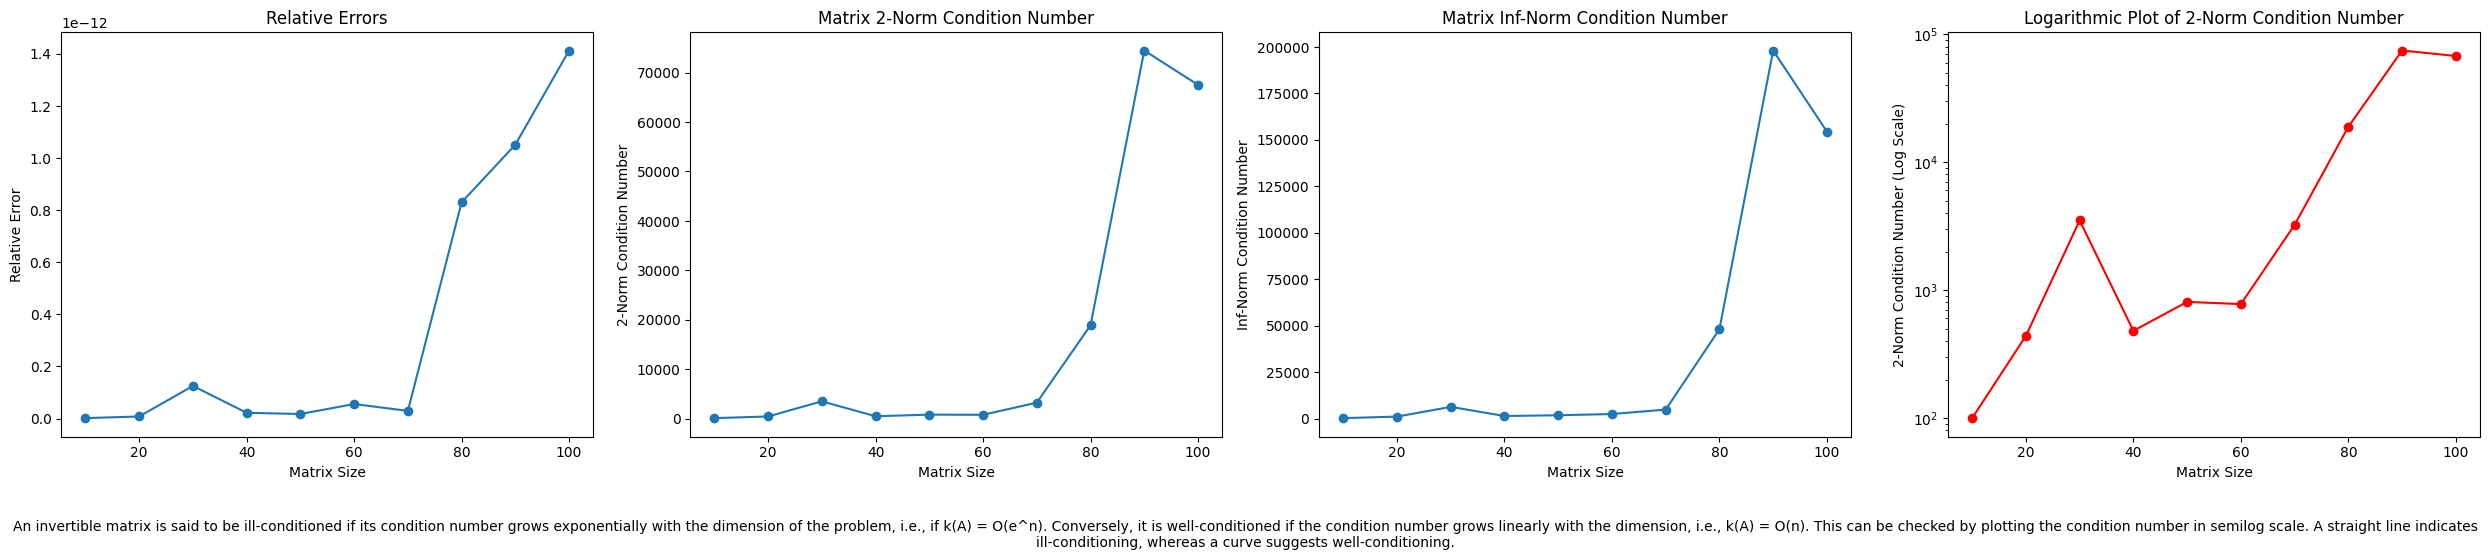

In [21]:

# for random matrices

size = np.linspace(10, 100, num=10, dtype=np.int32)
errs = []
cond_nums = []

for n in size:
    A = np.random.rand(n, n)
    x_true = np.ones((n, 1))
    b = A @ x_true

    norm_2 = np.linalg.cond(A, p=2)
    norm_inf = np.linalg.cond(A, p=np.inf)
    cond_nums.append((norm_2, norm_inf))
    # print(n, norm_2)

    x_estimate = np.linalg.solve(A, b)
    relative_err = np.linalg.norm(x_true - x_estimate) / np.linalg.norm(x_true)
    print(f"for n={n} The relative error is {relative_err}")


    errs.append(relative_err)

# Plotting
fig, axes = plt.subplots(1, 4, figsize=(25, 5))

# Relative errors
axes[0].plot(size, errs, marker='o')
axes[0].set_title("Relative Errors")
axes[0].set_xlabel("Matrix Size")
axes[0].set_ylabel("Relative Error")

# 2-norm condition numbers
axes[1].plot(size, [x[0] for x in cond_nums], marker='o')
axes[1].set_title("Matrix 2-Norm Condition Number")
axes[1].set_xlabel("Matrix Size")
axes[1].set_ylabel("2-Norm Condition Number")

# Infinity-norm condition numbers
axes[2].plot(size, [x[1] for x in cond_nums], marker='o')
axes[2].set_title("Matrix Inf-Norm Condition Number")
axes[2].set_xlabel("Matrix Size")
axes[2].set_ylabel("Inf-Norm Condition Number")

# Logarithmic plot of 2-norm condition numbers
axes[3].semilogy(size, [x[0] for x in cond_nums], marker='o', color='red')
axes[3].set_title("Logarithmic Plot of 2-Norm Condition Number")
axes[3].set_xlabel("Matrix Size")
axes[3].set_ylabel("2-Norm Condition Number (Log Scale)")

plt.tight_layout()

# Explanation of the behavior
plt.figtext(
    0.5, -0.1, 
    "An invertible matrix is said to be ill-conditioned if its condition number grows exponentially with the dimension of the problem, "
    "i.e., if k(A) = O(e^n). Conversely, it is well-conditioned if the condition number grows linearly with the dimension, "
    "i.e., k(A) = O(n). This can be checked by plotting the condition number in semilog scale. A straight line indicates "
    "ill-conditioning, whereas a curve suggests well-conditioning.",
    wrap=True, horizontalalignment="center", fontsize=10
)

plt.show()

As you can see, the error is very small. This is due to two aspects of the problem:

The algorithm is stable (i.e. it does not amplify the errors on A)
The matrix A is “well-behaved”, i.e. its inverse does not amplifies the errors on y We say that **A is well-conditioned** , as opposed to ill-conditioned matrices.


## Hilbert and Vandermonde Matrices

### **Hilbert Matrix**
A **Hilbert matrix** is defined as:
$$
H_{i,j} = \frac{1}{i + j - 1}, \quad i, j = 1, 2, \dots, n
$$

#### **Key Features**:
- **Symmetric** matrix (\(H = H^T\)).
- Entries decrease as you move away from the top-left corner.
- **Ill-conditioned** for larger sizes, making numerical solutions unstable.

#### **Example** (\(n = 3\)):
$$
H = \begin{bmatrix}
1 & \frac{1}{2} & \frac{1}{3} \\
\frac{1}{2} & \frac{1}{3} & \frac{1}{4} \\
\frac{1}{3} & \frac{1}{4} & \frac{1}{5}
\end{bmatrix}
$$

---

### **Vandermonde Matrix**
A **Vandermonde matrix** is constructed from a sequence of numbers \(x_1, x_2, \dots, x_n\), where:
$$
V_{i,j} = x_i^{j-1}, \quad i = 1, 2, \dots, n \quad j = 1, 2, \dots, n
$$

#### **Key Features**:
- Rows correspond to geometric progressions.
- Determinant:
$$
\text{det}(V) = \prod_{1 \leq i < j \leq n} (x_j - x_i)
$$
  Singular if any \(x_i = x_j\).

#### **Example** (\(n = 3, x = [1, 2, 3]\)):
$$
V = \begin{bmatrix}
1 & 1 & 1 \\
1 & 2 & 4 \\
1 & 3 & 9
\end{bmatrix}
$$

---

### **Comparison**

| Feature              | Hilbert Matrix                              | Vandermonde Matrix                         |
|----------------------|---------------------------------------------|-------------------------------------------|
| **Definition**       | \(\frac{1}{i+j-1}\)                         | \(x_i^{j-1}\)                              |
| **Symmetry**         | Symmetric                                   | Not symmetric                              |
| **Conditioning**     | Very ill-conditioned                        | Can be ill-conditioned (depends on \(x_i\)) |
| **Applications**     | Stability testing in numerical analysis     | Polynomial interpolation, signal processing |

for n=5 The relative error is 1.6138325005976652e-13
for n=10 The relative error is 7.93374705598835e-09
for n=15 The relative error is 257.0866506355987
for n=20 The relative error is 237418520625.5743
for n=25 The relative error is 1.296154488781151e+20
for n=30 The relative error is 5.225310494699482e+25


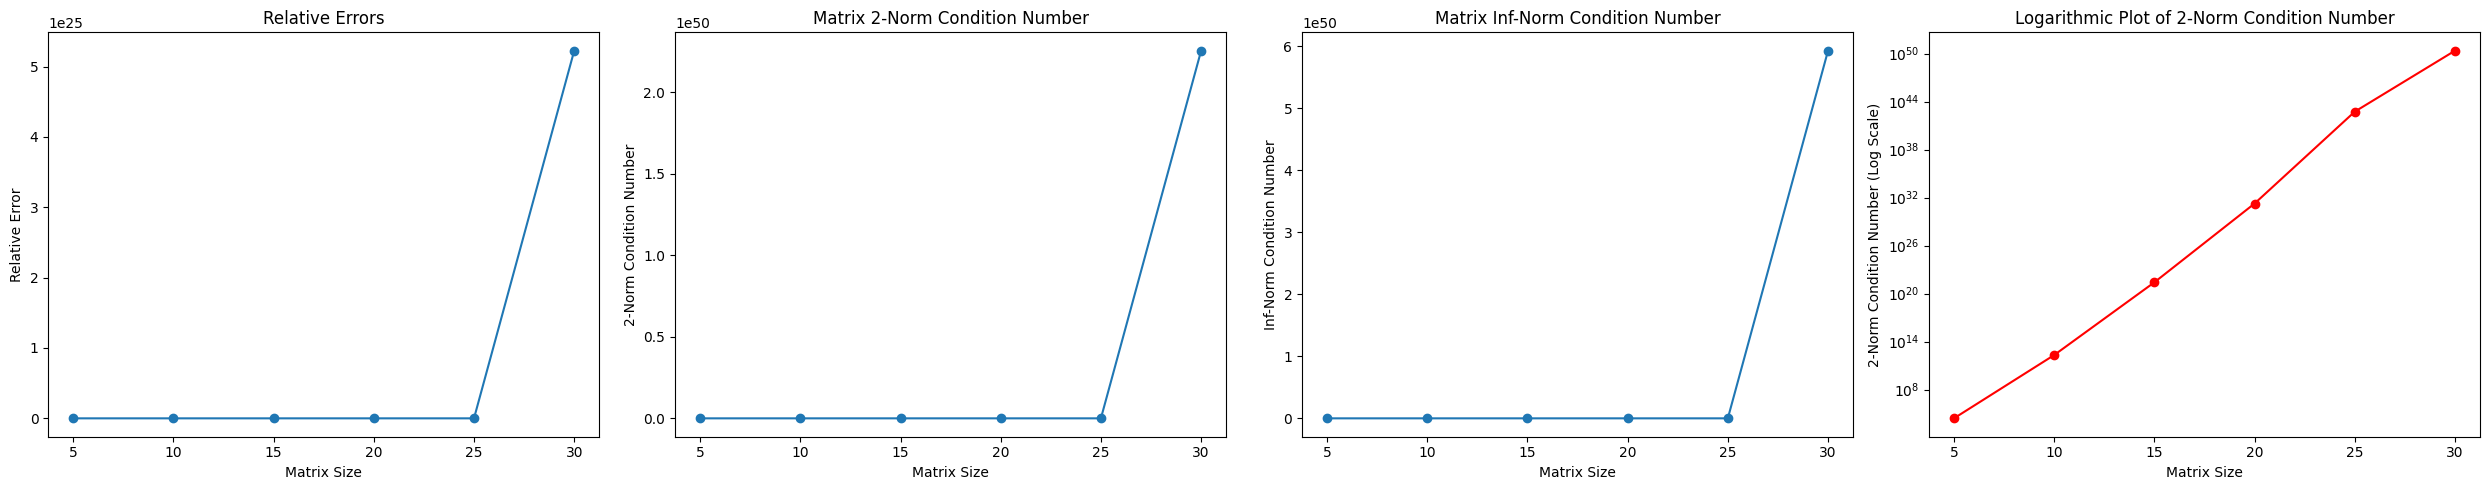

In [19]:
#Vandermonde Matrix
size = np.linspace(5, 30, num = 6, dtype = np.int32)
errs = []
cond_nums = []
for n in size:
    x_true = np.ones((n,1), dtype = np.float64)
    A= np.vander(np.linspace(1, n, n))
    b = A @ x_true
    
    norm_2 = np.linalg.cond(A)
    norm_inf = np.linalg.cond(A, p = np.inf)
    cond_nums.append((norm_2, norm_inf))
    # print(n, norm_2)
    x_estimate = np.linalg.solve(A, b)
    relative_err = np.linalg.norm(x_true - x_estimate)/np.linalg.norm(x_true)
    print(f"for n={n} The relative error is {relative_err}")

    errs.append(relative_err)

# Plotting
fig, axes = plt.subplots(1, 4, figsize=(25, 5))

# Relative errors
axes[0].plot(size, errs, marker='o')
axes[0].set_title("Relative Errors")
axes[0].set_xlabel("Matrix Size")
axes[0].set_ylabel("Relative Error")

# 2-norm condition numbers
axes[1].plot(size, [x[0] for x in cond_nums], marker='o')
axes[1].set_title("Matrix 2-Norm Condition Number")
axes[1].set_xlabel("Matrix Size")
axes[1].set_ylabel("2-Norm Condition Number")

# Infinity-norm condition numbers
axes[2].plot(size, [x[1] for x in cond_nums], marker='o')
axes[2].set_title("Matrix Inf-Norm Condition Number")
axes[2].set_xlabel("Matrix Size")
axes[2].set_ylabel("Inf-Norm Condition Number")

# Logarithmic plot of 2-norm condition numbers
axes[3].semilogy(size, [x[0] for x in cond_nums], marker='o', color='red')
axes[3].set_title("Logarithmic Plot of 2-Norm Condition Number")
axes[3].set_xlabel("Matrix Size")
axes[3].set_ylabel("2-Norm Condition Number (Log Scale)")

plt.tight_layout()

for n=4 The relative error is 3.1234482701862956e-14
for n=5 The relative error is 1.0031320641856848e-11
for n=6 The relative error is 9.428804424908709e-11
for n=7 The relative error is 9.360079760253215e-09
for n=8 The relative error is 8.309270755509753e-08
for n=9 The relative error is 2.5979863071540282e-06
for n=10 The relative error is 0.0004336840147501142
for n=11 The relative error is 0.0037665637724781206
for n=12 The relative error is 0.06684188824258049


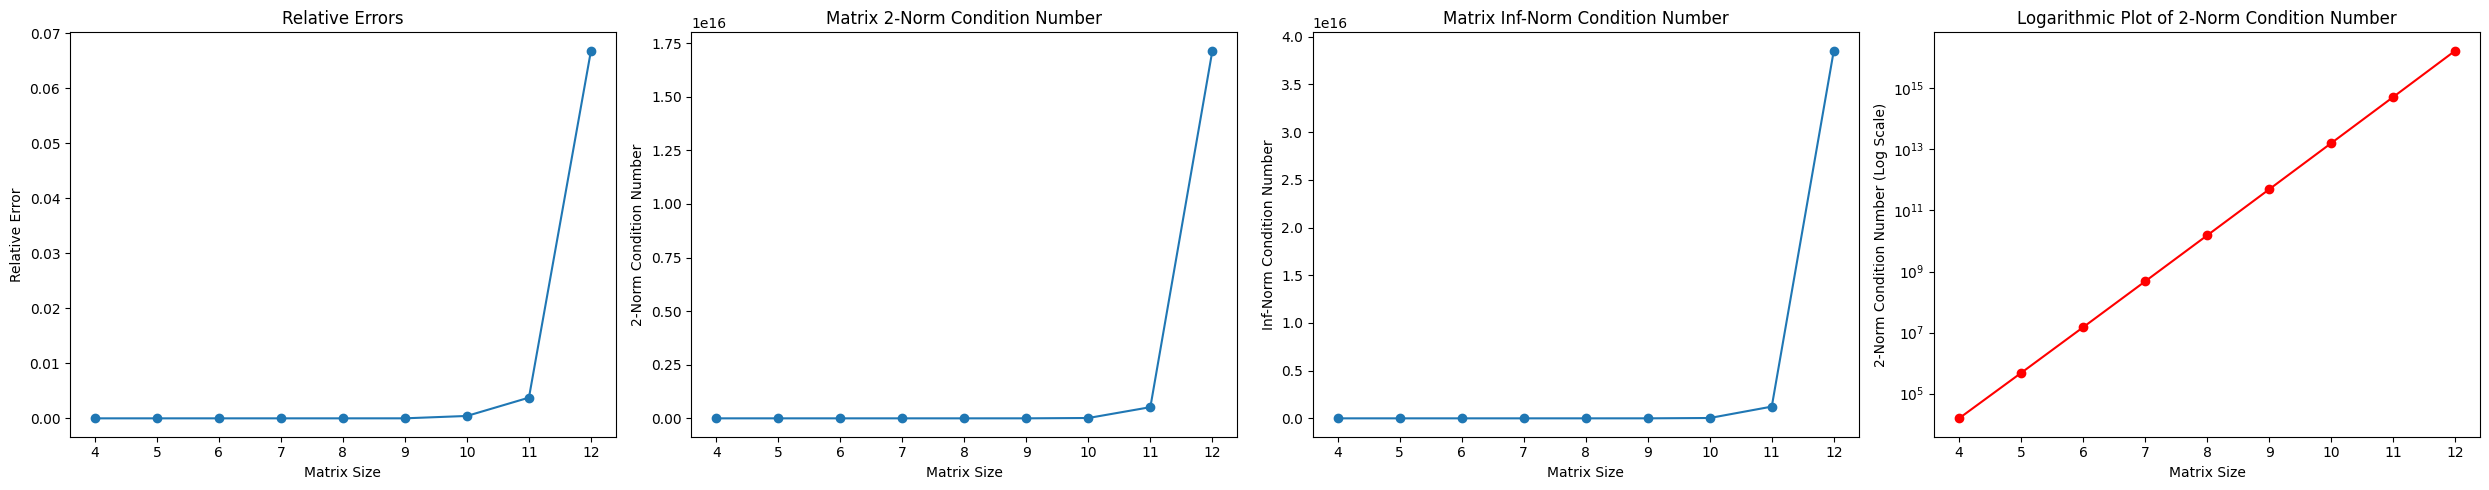

In [20]:
#Hilbert Matrix

size = np.linspace(4, 12, num = 9, dtype = np.int32)
errs = []
cond_nums = []
for n in size:
    x_true = np.ones((n,1))
    A= hilbert(n)
    b = A @ x_true
    
    norm_2 = np.linalg.cond(A)
    norm_inf = np.linalg.cond(A, p = np.inf)
    cond_nums.append((norm_2, norm_inf))
    x_estimate = np.linalg.solve(A, b)
    relative_err = np.linalg.norm(x_true - x_estimate)/np.linalg.norm(x_true)
    print(f"for n={n} The relative error is {relative_err}")

    errs.append(relative_err)
    
# Plotting
fig, axes = plt.subplots(1, 4, figsize=(25, 5))

# Relative errors
axes[0].plot(size, errs, marker='o')
axes[0].set_title("Relative Errors")
axes[0].set_xlabel("Matrix Size")
axes[0].set_ylabel("Relative Error")

# 2-norm condition numbers
axes[1].plot(size, [x[0] for x in cond_nums], marker='o')
axes[1].set_title("Matrix 2-Norm Condition Number")
axes[1].set_xlabel("Matrix Size")
axes[1].set_ylabel("2-Norm Condition Number")

# Infinity-norm condition numbers
axes[2].plot(size, [x[1] for x in cond_nums], marker='o')
axes[2].set_title("Matrix Inf-Norm Condition Number")
axes[2].set_xlabel("Matrix Size")
axes[2].set_ylabel("Inf-Norm Condition Number")

# Logarithmic plot of 2-norm condition numbers
axes[3].semilogy(size, [x[0] for x in cond_nums], marker='o', color='red')
axes[3].set_title("Logarithmic Plot of 2-Norm Condition Number")
axes[3].set_xlabel("Matrix Size")
axes[3].set_ylabel("2-Norm Condition Number (Log Scale)")

plt.tight_layout()

From the plots, we can conclude these results:

1-Relative Error, norm_2 and norm_inf bahave the same.

2-Norm_2 and Norm_inf have the same magnitude and as a result condition number is not related to the type of the norm.

. Due to the equivalence of norms(In finite-dimensional spaces, all norms are equivalent.), the magnitude of the condition number does not depend of p(for a p-norm)

. Norms may differ numerically but are bounded relative to each other.

3-For high condition numbers, we have high relative errors.

4-In the Random Matrix, although it has higher condition number in n=60, still the relative error is low so we can say it is not ill-conditioned.

5-In the Vandermonde Matrix, condition number goes exponentially high with increasing the dimention (n) and the relative error is high so we can say it is ill-conditioned.

6-In the Hilbert Matrix, condition number goes exponentially high with increasing the dimention (n), still the relative error don't get very high untill some dimention so we can say it is not ill-conditioned.


### machine epsilon


2.220446049250313e-16
At n = [16] the estimation is equal to 1


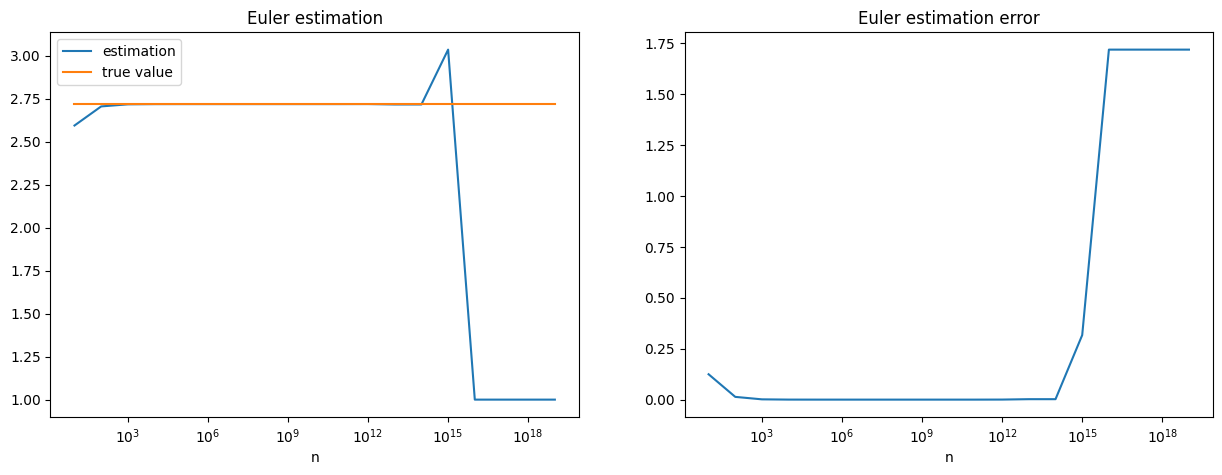

In [16]:
#Calculating Machine Epsilon:

epsilon = 1

while(1 + epsilon/2 > 1):
    epsilon /= 2

print(epsilon)

#Ilastrating Euler Constants:

def euler_calc(n):
     return (1 + 1/n) ** n, np.abs(np.e - (1 + 1/n) ** n)

est = []
err = []
x = []

fig, axes = plt.subplots(1,2, figsize=(15,5))
for i in range(1,20):
    e_estimation, e_error = euler_calc(10 ** i)
    est.append(e_estimation)
    err.append(e_error)
    x.append(10 ** i)

axes[0].plot(x, est)
axes[0].plot(x, np.e*np.ones((len(x))))
axes[0].set_title('Euler estimation')
# axes[0].yscale('log')
axes[0].set_xscale('log')
axes[0].set_xlabel('n')
axes[0].legend(['estimation','true value'])

axes[1].plot(x, err)
axes[1].set_title('Euler estimation error')
# axes[1].yscale('log')
axes[1].set_xscale('log')
axes[1].set_xlabel('n')

# we add 1 to the np.argwhere (which gives index not the value) output to obtain the value of n
print(f'At n = {np.argwhere(np.array(est)==1)[0] + 1} the estimation is equal to 1')
plt.show()

### The code first calculates the machine epsilon, which is the smallest positive number ε such that 1 + ε/2 > 1 does not hold.
The result of 2.220446049250313e-16 is the machine epsilon for the system, which is the precision limit of floating-point arithmetic in this environment. It indicates the smallest difference that can be distinguished from 1.0 due to rounding errors in numerical calculations. This value is typical for double-precision floating-point (64-bit) arithmetic, and it suggests the accuracy up to approximately 16 decimal places.



### Euler Estimation
Equal to 1: The print statement indicates that at n = 16, the Euler estimation is exactly 1. This is an interesting result and may seem counterintuitive, as the true value of e is approximately 2.718. The estimation formula  approximates e for large n, but it may exhibit rounding errors or specific behavior in certain computational steps. The result suggests that due to the finite precision of floating-point arithmetic, the estimation formula evaluates to 1 when the number of terms is relatively small, before accurately converging to the value of e.




In [7]:
#relation between the eigenvalues and the full-rank condition:

A = np.array([[4,2], [1,3]])
B = np.array([[4,2], [2,1]])
print("rank of A is : ", np.linalg.matrix_rank(A))
print("eigen values of A are: ",np.linalg.eigvals(A))

print("\nrank of B is : ", np.linalg.matrix_rank(B))
print("eigen values of B are: ",np.linalg.eigvals(B))

rank of A is :  2
eigen values of A are:  [5. 2.]

rank of B is :  1
eigen values of B are:  [5. 0.]


In [8]:
A = np.array([[5,6], [2,3]])
print("rank of A is : ", np.linalg.matrix_rank(A))
print("eigen values of A are: ",np.linalg.eigvals(A))


rank of A is :  2
eigen values of A are:  [7.60555128 0.39444872]


Result:

rank of a matrix is equal to the number of non-zero eigenvalues.

### Analysis of Matrix Rank and Eigenvalues

Here are the computed results:

1. **Matrix \( A_1 \):**
   - **Rank:** \( 2 \)
   - **Eigenvalues:** \( [5, 2] \)

2. **Matrix \( B \):**
   - **Rank:** \( 1 \)
   - **Eigenvalues:** \( [5, 0] \)

3. **Matrix \( A_2 \):**
   - **Rank:** \( 2 \)
   - **Eigenvalues:** \( [7.60555128, 0.39444872] \)

---

### Full-Rank Condition and Eigenvalues

- A matrix is **full-rank** if its rank equals the smallest dimension of the matrix (number of rows or columns).
- The eigenvalues of a matrix provide insight into its rank:
  - If **any eigenvalue is zero**, the matrix is not full-rank because the determinant is zero, indicating linear dependence in its rows/columns.
  - If **all eigenvalues are non-zero**, the matrix is full-rank.

---

### Observations

1. \( A_1 \) is full-rank (rank = 2 ), and its eigenvalues are \( [5, 2] \), both non-zero.
2. \( B \) is not full-rank (rank = 1 ), and one eigenvalue is \( 0 \).
3. \( A_2 \) is full-rank (rank = 2 ), and all eigenvalues are non-zero.

---

### Deduction

The relationship between eigenvalues and rank is consistent across examples:
- The presence of a zero eigenvalue indicates that the matrix is not full-rank.
- Non-zero eigenvalues suggest the matrix is full-rank.

In [11]:
# test on other matrixs
import numpy as np

# Define more matrices
F = np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]])  # A zero matrix (completely singular)
G = np.array([[1, 1], [1, 1]])                  # A rank-deficient matrix (linearly dependent rows)
H = np.eye(4)                                  # Identity matrix (full-rank)

# Compute rank and eigenvalues for each new matrix
rank_F = np.linalg.matrix_rank(F)
eigvals_F = np.linalg.eigvals(F)

rank_G = np.linalg.matrix_rank(G)
eigvals_G = np.linalg.eigvals(G)

rank_H = np.linalg.matrix_rank(H)
eigvals_H = np.linalg.eigvals(H)

# More examples: Random matrices
np.random.seed(42)  # For reproducibility
I = np.random.rand(4, 4)                       # A random 4x4 matrix (likely full-rank)
J = np.random.rand(3, 5)                       # Rectangular matrix

# Compute rank and eigenvalues for these matrices
rank_I = np.linalg.matrix_rank(I)
eigvals_I = np.linalg.eigvals(I)

rank_J = np.linalg.matrix_rank(J)  # Note: Eigenvalues aren't defined for non-square matrices

# Collect all results
results = {
    "F (Zero Matrix)": {"Rank": rank_F, "Eigenvalues": eigvals_F.tolist()},
    "G (Rank-Deficient Matrix)": {"Rank": rank_G, "Eigenvalues": eigvals_G.tolist()},
    "H (Identity Matrix)": {"Rank": rank_H, "Eigenvalues": eigvals_H.tolist()},
    "I (Random 4x4)": {"Rank": rank_I, "Eigenvalues": eigvals_I.tolist()},
    "J (Random 3x5)": {"Rank": rank_J, "Eigenvalues": "N/A (Non-square matrix)"},
}
output = "\n".join(
    f"{key}:\n  Rank: {value['Rank']}\n  Eigenvalues: {value['Eigenvalues']}"
    for key, value in results.items()
)
print(output)


F (Zero Matrix):
  Rank: 0
  Eigenvalues: [0.0, 0.0, 0.0]
G (Rank-Deficient Matrix):
  Rank: 1
  Eigenvalues: [2.0, 0.0]
H (Identity Matrix):
  Rank: 4
  Eigenvalues: [1.0, 1.0, 1.0, 1.0]
I (Random 4x4):
  Rank: 4
  Eigenvalues: [(1.837206116234975+0j), (-0.3943213297048897+0.5522955225287366j), (-0.3943213297048897-0.5522955225287366j), (-0.314039813492394+0j)]
J (Random 3x5):
  Rank: 3
  Eigenvalues: N/A (Non-square matrix)
